<a href="https://colab.research.google.com/github/varsh23-p/---/blob/main/Mental_Health_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**
# Mental Health Text Classification System

This project focuses on predicting mental health conditions such as depression, anxiety, and stress using machine learning techniques. In today’s digital world, people often express their thoughts and emotions through text, which can be analyzed to identify mental health risks. The objective of this project is to build a predictive model that can classify a person’s mental health condition based on their written statements. By applying natural language processing and machine learning algorithms, this system helps in early detection and awareness of mental health issues.




Step 1: Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Combined Data.csv to Combined Data (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("Combined Data.csv")

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


Step 2: Data Cleaning

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     52681 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


Step 3: Understanding Target Variable

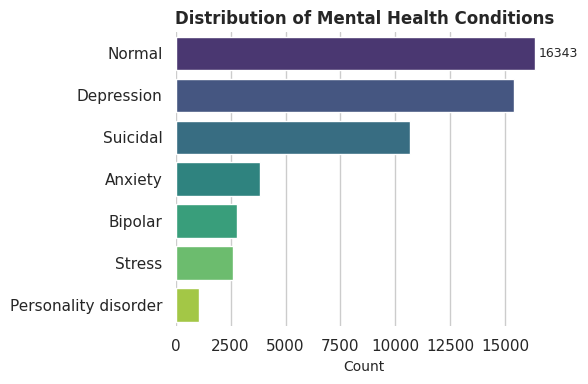

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['status'].value_counts()


sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=counts.values,
    y=counts.index,
    hue=counts.index,
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Distribution of Mental Health Conditions", fontsize=12, fontweight='bold')
ax.set_xlabel("Count", fontsize=10)
ax.set_ylabel(None)

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Step 4: Text Preprocessing

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['statement'] = df['statement'].apply(clean_text)

Step 5: Feature Extraction (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['statement'])   # ❗ remove .toarray()
y = df['status']

print("X :", X)
print("Y :", y)

X : <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4410915 stored elements and shape (52681, 4000)>
  Coords	Values
  (0, 2500)	0.952546285001767
  (0, 2225)	0.30439378267194084
  (1, 3607)	0.41145269780835314
  (1, 2949)	0.37787691257875805
  (1, 736)	0.4135997898822789
  (1, 2160)	0.29055836823039777
  (1, 2803)	0.43925706270205495
  (1, 1463)	0.3218013126699103
  (1, 67)	0.16514531224329596
  (1, 2577)	0.1766596051946104
  (1, 2445)	0.12214454783804579
  (1, 2583)	0.25004605989111345
  (2, 2803)	0.6635723681058342
  (2, 67)	0.12474001584943514
  (2, 3947)	0.2233848854445154
  (2, 394)	0.17055158408345109
  (2, 2492)	0.18473772750569997
  (2, 1202)	0.2787086914181058
  (2, 923)	0.32409142976507727
  (2, 3054)	0.24011089202490332
  (2, 1605)	0.09907334446452461
  (2, 153)	0.08162466727616989
  (2, 2671)	0.22612789439947073
  (2, 3055)	0.3507363602264015
  (3, 2225)	0.12648760409736295
  :	:
  (52680, 1433)	0.08222393167004177
  (52680, 2541)	0.11769991819249093
  (52680

STEP 5: Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['status'])

Step 7: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42144, 4000)
X_test: (10537, 4000)
y_train: (42144,)
y_test: (10537,)


Step 8: Model Building

*✅ Logistic Regression*




In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=200)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
y_pred1

array([6, 1, 6, ..., 3, 3, 6])

*✅ Naive Bayes (BEST for text)*

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model2 = MultinomialNB()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
y_pred2

array([6, 3, 6, ..., 2, 3, 6])

*✅ Support Vector Machine (SVM)*

In [ ]:
from sklearn.svm import LinearSVC

model3 = LinearSVC()
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)
y_pred3

array([6, 1, 6, ..., 3, 3, 6])

*✅ Random Forest*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model4 = RandomForestClassifier()
model4.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)
y_pred4

array([2, 1, 6, ..., 3, 3, 6])

Step 9: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, y_pred1))
print("Naive Bayes:", accuracy_score(y_test, y_pred2))
print("Support Vector Machine (SVM):", accuracy_score(y_test, y_pred3))
print("Random Forest:", accuracy_score(y_test, y_pred4))

Logistic: 0.7705229192369745
Naive Bayes: 0.682452310904432
Support Vector Machine (SVM): 0.7714719559646959
Random Forest: 0.7150042706652747


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("🔹 Logistic Regression Report:\n")
print(classification_report(y_test, y_pred1, target_names=le.classes_))

print("\n🔹 Naive Bayes Report:\n")
print(classification_report(y_test, y_pred2, target_names=le.classes_))

print("\n🔹 SVM Report:\n")
print(classification_report(y_test, y_pred3, target_names=le.classes_))

print("\n🔹 Random Forest Report:\n")
print(classification_report(y_test, y_pred4, target_names=le.classes_))

🔹 Logistic Regression Report:

                      precision    recall  f1-score   support

             Anxiety       0.82      0.71      0.76       768
             Bipolar       0.86      0.66      0.75       556
          Depression       0.70      0.75      0.72      3081
              Normal       0.86      0.96      0.91      3269
Personality disorder       0.84      0.47      0.60       215
              Stress       0.66      0.44      0.53       517
            Suicidal       0.71      0.67      0.69      2131

            accuracy                           0.77     10537
           macro avg       0.78      0.67      0.71     10537
        weighted avg       0.77      0.77      0.77     10537


🔹 Naive Bayes Report:

                      precision    recall  f1-score   support

             Anxiety       0.74      0.60      0.67       768
             Bipolar       0.87      0.45      0.59       556
          Depression       0.55      0.74      0.63      3081
           

Step 10: Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model3, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.69801651 0.74212225 0.70615034 0.75417616 0.70548595]
Average accuracy: 0.7211902426629985


Step 11: Final Prediction

In [ ]:
def predict_mental_health(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = model3.predict(vec)
    return le.inverse_transform(pred)[0]

In [ ]:
test_samples = [
    "I feel happy and relaxed today",
    "I feel very sad and hopeless",
    "I am always worried and anxious",
    "I have too much stress and pressure",
    "I want to end my life",
    "I feel extremely energetic sometimes and very low other times"
]

for text in test_samples:
    print(text, "→", predict_mental_health(text))

I feel happy and relaxed today → Normal
I feel very sad and hopeless → Depression
I am always worried and anxious → Anxiety
I have too much stress and pressure → Stress
I want to end my life → Suicidal
I feel extremely energetic sometimes and very low other times → Depression


In [ ]:
!pip install ipywidgets

In [ ]:
from IPython.display import display
import ipywidgets as widgets

In [ ]:

# ===================== LABEL MAPPING =====================
label_mapping = {
    0: "Anxiety",
    1: "Bipolar",
    2: "Depression",
    3: "Normal",
    4: "Personality disorder",
    5: "Stress",
    6: "Suicidal"
}

# ===================== COLOR THEME =====================
THEME_BG = "#f3e8ff"        # Light lavender
TITLE_COLOR = "#5b2b82"    # Dark purple
BTN_COLOR = "#c084fc"      # Button color
CARD_BG = "#faf5ff"        # Result card
BORDER_COLOR = "#d8b4fe"   # Border

# ===================== TITLE =====================
title = widgets.HTML(
    value=f"""
    <div style="
        background-color:{THEME_BG};
        padding:16px;
        border-radius:14px;
        text-align:center;
        font-family:Arial;">
        <h2 style="color:{TITLE_COLOR}; margin-bottom:5px;">
            🧠 Mental Health Text Analyzer
        </h2>
        <p style="color:#4b1d6b; font-size:14px;">
            MLA Project using Machine Learning & NLP
        </p>
    </div>
    """
)

# ===================== INSTRUCTION =====================
instruction = widgets.HTML(
    value="""
    <p style="
        text-align:center;
        font-size:17px;
        font-weight:bold;
        color:#C9BEFF;">
        Enter a sentence describing your feelings:
    </p>
    """
)
# ===================== TEXT INPUT =====================
text_input = widgets.Textarea(
    placeholder="Example: I feel nervous and stressed about my exams and future...",
    layout=widgets.Layout(
        width="95%",
        height="120px"
    )
)

# ===================== BUTTON =====================
predict_button = widgets.Button(
    description="Predict Mental Health Status",
    layout=widgets.Layout(width="350px")
)
predict_button.style.button_color = BTN_COLOR
predict_button.style.font_weight = "bold"

# ===================== OUTPUT =====================
output = widgets.Output()

# ===================== PREDICTION FUNCTION =====================
def on_predict_clicked(b):
    output.clear_output()
    user_text = text_input.value.strip()

    if user_text == "":
        with output:
            print("⚠️ Please enter some text.")
        return

    # Prediction
    cleaned = clean_text(user_text)
    vectorized = vectorizer.transform([cleaned])
    predicted_class = model3.predict(vectorized)[0]
    predicted_label = label_mapping[int(predicted_class)]

    # Display result
    with output:
        display(widgets.HTML(
            value=f"""
            <div style="
                background-color:{CARD_BG};
                padding:20px;
                border-radius:14px;
                border:2px solid {BORDER_COLOR};
                font-family:Arial;
                width:95%;
                word-wrap:break-word;
                line-height:1.6;">

               <p style="font-size:15px; color:#1e3a8a;">
    <b>✅ Input Text:</b><br>
    <span style="color:#111827;">
        {user_text}
    </span>
</p>

<p style="font-size:19px; margin-top:12px; color:#be185d;">
    <b>🧠 Predicted Mental Health Condition:</b><br>
    <span style="color:{TITLE_COLOR}; font-size:22px;">
        <b>{predicted_label}</b>
    </span>
</p>
``
            </div>
            """
        ))

# ===================== BUTTON ACTION =====================
predict_button.on_click(on_predict_clicked)

# ===================== DISPLAY UI =====================
ui = widgets.VBox([
    title,
    instruction,
    text_input,
    predict_button,
    output
])

display(ui)